# Project 3
# Mental Health and CGPA: A Classification Study of Student Performance

https://www.kaggle.com/datasets/sonia22222/students-mental-health-assessments/data

## Introductions
**Michael Shahine** uniqname: *shahine*

Hi teaching team, I am a first year MSI student I come from a background mainly in front end development and was interested in MSI based on a recommendation from my friend in the program + an interest in Basketball analytics and business analytics. I play club Water Polo for the University in my free time, and play a lot basketball as well.

**Rebecca Falash:** uniqname: *rfalash*

I am a second year Dual degree student studying Geospatial data science at SEAS and Big Data at UMSI. I am interested in electrification, environmental modeling, and load analysis. In my free time I race on the UM cycling team. 

**Mason Fisher:** uniqname: *masonaf*

Hi teaching team, I am a first year MSI student. I come from a background in commmunications, but I am currently working for the football team as a sports scientist. I am interesting in sports analytics. In my free time, I enjoy reading and playing basketball. 


**Overview**

As a team we decided to study the influence of social media and outward pressures on a students performance at school. The previous two projects used a merged dataset that had been grouped on age and gender. After further review, this method of combining was not the most beneficial so moving forward we are just using a single, student mental health data source from kraggle.  This dataset will help us identify mental health patterns that are connected a students CGPA. Features within the data source include stress, depression, anxiety levels, etc. 

**Motivation**
We chose this topic for our project because we understand the pressures that come with being a student. As a team we wanted to better understand how outside factors can influence our mental health. We wanted to see what sort of habits have an effect on us as students and if there was any differences based off of things like age, gender, gpa etc. This is more and more relevant with the increasing amount of technology nowadays and the less and less time people are spending doing outside activities, making researching this even more important. We take a deeper look at this below and start to paint a picture. 

**Data Sources**

1. https://www.kaggle.com/datasets/sonia22222/students-mental-health-assessments/data


# Machine Learning Goal
1. How does Mental Health Factors Affect GPA
- We will look at this through classification 

## Preprocessing Data

In [19]:
import csv
import json
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.decomposition import PCA
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix,roc_auc_score,accuracy_score, f1_score, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from sklearn.model_selection import GridSearchCV

In [3]:
df = pd.read_csv('df_MH_export.csv')

### Data cleaning and handling of issues: 20 points


In [4]:
print("Missing by column:\n", df.isna().sum().sort_values(ascending=False))

Missing by column:
 Substance_Use                  15
CGPA                           12
Course                          0
Age                             0
Gender                          0
Stress_Level                    0
Anxiety_Score                   0
Depression_Score                0
Physical_Activity               0
Diet_Quality                    0
Social_Support                  0
Sleep_Quality                   0
Relationship_Status             0
Counseling_Service_Use          0
Family_History                  0
Chronic_Illness                 0
Financial_Stress                0
Extracurricular_Involvement     0
Semester_Credit_Load            0
Residence_Type                  0
dtype: int64


In [5]:
df = df.dropna(subset=["CGPA"]) #remove rows with missing CGPA because its our target variable

df["CGPA_bin"] = pd.qcut(
    df["CGPA"],
    q=3,  # 3 quantile bins (tertiles)
    labels=["low", "medium", "high"]
)
df = df.drop(columns=["CGPA"]) #drop CGPA from the features dataframe

df.head()

,Age,Course,Gender,Stress_Level,Depression_Score,Anxiety_Score,Sleep_Quality,Physical_Activity,Diet_Quality,Social_Support,Relationship_Status,Substance_Use,Counseling_Service_Use,Family_History,Chronic_Illness,Financial_Stress,Extracurricular_Involvement,Semester_Credit_Load,Residence_Type,CGPA_bin
0,25,Others,Male,3,3,2,Good,Moderate,Good,Moderate,Married,Never,Never,No,No,2,Moderate,17,On-Campus,medium
1,24,Engineering,Female,0,3,0,Average,Low,Average,Low,Single,Occasionally,Occasionally,No,No,3,Low,27,On-Campus,low
2,19,Business,Female,4,0,3,Good,Low,Average,Moderate,In a Relationship,Never,Occasionally,No,No,4,High,15,On-Campus,high
3,19,Computer Science,Male,2,1,0,Average,Low,Average,Moderate,Single,NaN,Never,No,No,4,Moderate,20,Off-Campus,high
4,18,Business,Male,3,3,4,Good,Low,Average,High,Married,Never,Never,No,Yes,0,High,23,On-Campus,medium


For the initial data cleaning and handling we first checked for missing values. There were 12 missing values in the CGPA column which is our prediction variable. Because of that, we chose to drop all of those columns as filling them through the preprocessing stages would lead to incorrect conclusions. Then we used qcut to split the CGPA into 3 equal bins (low, medium, and high). It is also import that the original CGPA column is dropped before splitting as this can highly influence the prediction.

### Feature scaling and normalization; one-hot encoding/categorical variable handling (Baseline Models Path): 20 points

**Note:** CatBoost uses a separate preprocessing path (shown above). Below we show the one-hot encoding + PCA approach for baseline models (Decision Tree, Random Forest, SVM).



Rather then predicting the raw number, we created bins to sort out the CGPA into 3 different sections (low, medium, and high)

In [6]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["CGPA_bin"]  # keeps class balance
)

# separate features/target
X_train = train_df.drop(columns=["CGPA_bin"])
y_train = train_df["CGPA_bin"]
X_test  = test_df.drop(columns=["CGPA_bin"])
y_test  = test_df["CGPA_bin"]

print(f"Train: {X_train.shape}   Validation: {X_test.shape}")

Train: (5608, 19)   Validation: (1402, 19)


Before pre-processing the data, we split it into testing and training sets to avoid leakage. This will allow us to training the model on a subset of the whole data and use the remainder to validate the results. 

In [7]:
print("Train class counts:")
print(y_train.value_counts(dropna=False).sort_index())

print("\nTrain class proportions:")
print(y_train.value_counts(normalize=True, dropna=False).sort_index())

print("\nTest class counts:")
print(y_test.value_counts(dropna=False).sort_index())

print("\nTest class proportions:")
print(y_test.value_counts(normalize=True, dropna=False).sort_index())

Train class counts:
CGPA_bin
low       1887
medium    1926
high      1795
Name: count, dtype: int64

Train class proportions:
CGPA_bin
low       0.336484
medium    0.343438
high      0.320078
Name: proportion, dtype: float64

Test class counts:
CGPA_bin
low       471
medium    482
high      449
Name: count, dtype: int64

Test class proportions:
CGPA_bin
low       0.335949
medium    0.343795
high      0.320257
Name: proportion, dtype: float64


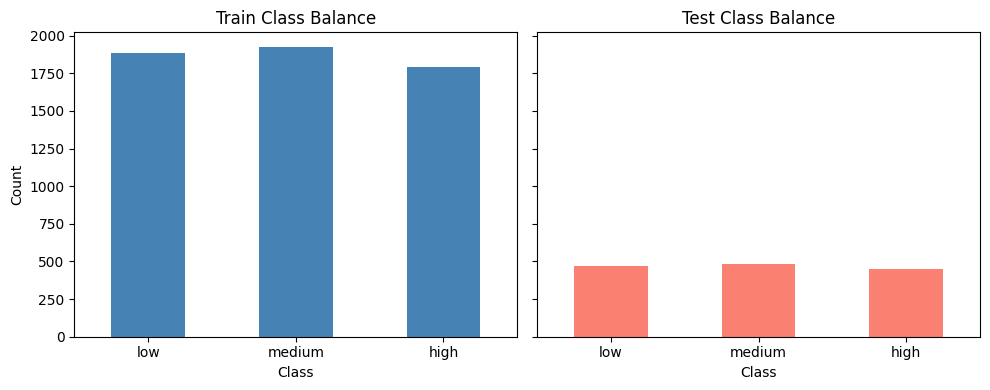

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

y_train.value_counts().sort_index().plot(
    kind="bar", ax=axes[0], title="Train Class Balance", color="steelblue"
)
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

y_test.value_counts().sort_index().plot(
    kind="bar", ax=axes[1], title="Test Class Balance", color="salmon"
)
axes[1].set_xlabel("Class")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

When splitting the data, it is important that there is class balance between the training and testing set. As seen in the table output as well as the plots, the proportions are nearly the same concluding they are balanced. Having balance ensures there will be limited bias during the training and testing process. The data output from above also confirms the class balance as each class is split into 1/3 of the total data. 

In [9]:
numeric_cols = X_train.select_dtypes(include='number').columns.tolist()
skewness = X_train[numeric_cols].skew().sort_values(key=lambda s: s.abs(), ascending=False)

print('Numeric feature skewness (sorted by absolute skew):')
print(skewness.round(2))

Numeric feature skewness (sorted by absolute skew):
Age                     0.76
Depression_Score        0.18
Anxiety_Score           0.12
Stress_Level            0.06
Financial_Stress        0.02
Semester_Credit_Load   -0.00
dtype: float64


Absolute skew is an important metric to include during preprocessing because it shows how asymmetric each numeric feature is within the data set. The output above shows low skew for all variables but age which is understandable considering the student demographic. 

In [10]:
print("\nUnique values for categorical features:")
categorical_cols = X_train.select_dtypes(include='object').columns.tolist()
for col in categorical_cols:
    print(f"{col}: {X_train[col].nunique()} unique values")


Unique values for categorical features:
Course: 6 unique values
Gender: 2 unique values
Sleep_Quality: 3 unique values
Physical_Activity: 3 unique values
Diet_Quality: 3 unique values
Social_Support: 3 unique values
Relationship_Status: 3 unique values
Substance_Use: 3 unique values
Counseling_Service_Use: 3 unique values
Family_History: 2 unique values
Chronic_Illness: 2 unique values
Extracurricular_Involvement: 3 unique values
Residence_Type: 3 unique values


In [ ]:
from sklearn.preprocessing import LabelEncoder
import time

num_cols = X_train.select_dtypes(include=["number"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

print(f"Numeric columns: {list(num_cols)}")
print(f"Categorical columns: {list(cat_cols)}")

cat_features_list = list(cat_cols)
print(f"Categorical features for CatBoost: {cat_features_list}")

X_train_cat_prep = X_train.copy()
X_test_cat_prep = X_test.copy()

imputer_num = SimpleImputer(strategy="median")
X_train_cat_prep[num_cols] = imputer_num.fit_transform(X_train_cat_prep[num_cols].values)
X_test_cat_prep[num_cols] = imputer_num.transform(X_test_cat_prep[num_cols].values)


label_encoders = {}
for col in cat_cols:
    X_train_cat_prep[col].fillna(X_train_cat_prep[col].mode()[0], inplace=True)
    X_test_cat_prep[col].fillna(X_train_cat_prep[col].mode()[0], inplace=True)
    le = LabelEncoder()
    X_train_cat_prep[col] = le.fit_transform(X_train_cat_prep[col].astype(str))
    X_test_cat_prep[col] = le.transform(X_test_cat_prep[col].astype(str))
    label_encoders[col] = le

# Scale numerics
scaler = StandardScaler()
X_train_cat_prep[num_cols] = scaler.fit_transform(X_train_cat_prep[num_cols])
X_test_cat_prep[num_cols] = scaler.transform(X_test_cat_prep[num_cols])

print(f"CatBoost training data shape: {X_train_cat_prep.shape}")

y_train_numeric = pd.Categorical(y_train).codes
y_test_numeric = pd.Categorical(y_test).codes

# GridSearch 
print("\nRunning GridSearchCV on CatBoost")
start_time = time.time()

param_grid = {
    'iterations': [100, 200],
    'depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2]
}

catboost_base = CatBoostClassifier(
    auto_class_weights='Balanced',
    verbose=0,
    random_state=42
)

grid_search = GridSearchCV(
    catboost_base,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_cat_prep, y_train_numeric, cat_features=cat_features_list)

elapsed = time.time() - start_time
print(f"GridSearch completed in {elapsed:.2f} seconds")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

# Evaluate best model on test set
catboost_model = grid_search.best_estimator_
y_pred_catboost = catboost_model.predict(X_test_cat_prep)
catboost_acc = accuracy_score(y_test_numeric, y_pred_catboost)
catboost_auc = roc_auc_score(y_test_numeric, catboost_model.predict_proba(X_test_cat_prep), multi_class='ovr', average='weighted')

print(f"\nCatBoost Test Accuracy: {catboost_acc:.4f}")
print(f"CatBoost Test AUC:      {catboost_auc:.4f}")

catboost_cv_acc = catboost_acc

Numeric columns: ['Age', 'Stress_Level', 'Depression_Score', 'Anxiety_Score', 'Financial_Stress', 'Semester_Credit_Load']
Categorical columns: ['Course', 'Gender', 'Sleep_Quality', 'Physical_Activity', 'Diet_Quality', 'Social_Support', 'Relationship_Status', 'Substance_Use', 'Counseling_Service_Use', 'Family_History', 'Chronic_Illness', 'Extracurricular_Involvement', 'Residence_Type']
Categorical features for CatBoost: ['Course', 'Gender', 'Sleep_Quality', 'Physical_Activity', 'Diet_Quality', 'Social_Support', 'Relationship_Status', 'Substance_Use', 'Counseling_Service_Use', 'Family_History', 'Chronic_Illness', 'Extracurricular_Involvement', 'Residence_Type']
CatBoost training data shape: (5608, 19)

Running GridSearchCV on CatBoost (this may take 1-2 minutes)...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
GridSearch completed in 632.16 seconds
Best parameters: {'depth': 6, 'iterations': 200, 'learning_rate': 0.2}
Best CV accuracy: 0.3406

CatBoost Test Accuracy: 0.358

## CatBoost Model

CatBoost is a gradient boosting algorithm that handles categorical features directly without one-hot encoding. Our dataset has 13 categorical features and 6 numeric features. We prepared the data by label-encoding the categorical columns and scaling the numeric columns. Then we used GridSearchCV to find the best hyperparameters (depth=6, iterations=200, learning_rate=0.2). 

The model achieved:
- **CV Accuracy: 0.3406**
- **Test Accuracy: 0.3588** 
- **Test AUC: 0.5124**

The low accuracy reflects the weak relationship between mental health factors and CGPA in this dataset, consistent with our mutual information analysis showing max MI about 0.015.


In [12]:
num_cols = X_train.select_dtypes(include=["number"]).columns
cat_cols = X_train.select_dtypes(include=["object"]).columns

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
])

X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print("Prepared shapes:", X_train_prep.shape, X_test_prep.shape)

Prepared shapes: (5608, 45) (1402, 45)


We split the training data into numeric and categorical data to apply the preprocessing pipeline. For numeric features, we used SimpleImputer(strategy="median") because the median is robust to outliers and helps minimize the impacts on skew. We then used StandardScaler because models we want to use like SVM are sensitive to feature scale, and standardizing helps each numeric feature contribute more evenly.

For categorical features, we used SimpleImputer(strategy="most_frequent") because replacing missing categories with the mode keeps values realistic and avoids creating fake labels. We then used OneHotEncoder because most models cannot directly use text categories, and one-hot encoding converts each category into a numeric indicator without creating a false order (low, medium, high --> 0, 1, 2).

Then applied both to the testing and training data to keep things consistent and avoid leakage.

### Dimensionality reduction techniques: 20 points



In [13]:
X_train_prep_dense = X_train_prep
X_test_prep_dense  = X_test_prep


pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train_prep_dense)
X_test_pca  = pca.transform(X_test_prep_dense)

print("Before PCA:", X_train_prep_dense.shape, X_test_prep_dense.shape)
print("After PCA: ", X_train_pca.shape, X_test_pca.shape)
print("Explained variance ratio (sum):", np.sum(pca.explained_variance_ratio_).round(4))


Before PCA: (5608, 45) (1402, 45)
After PCA:  (5608, 26) (1402, 26)
Explained variance ratio (sum): 0.9508


For dimensionality reduction techniques, we used PCA because our dataset contained many variables that could overlap and be highly correlated. Using PCA identified and removed the redundant features by combining ones that were correlated, which can reduce overfitting by just focusing on our data's most important patterns. In this case it reduced out columns from 45 to 26 significancy shrinking the size of our data. This will help our classification analysis run faster and more accurately.


### Preprocessing justification and impact analysis: 20 points

**To reiterate the decisions within the preprocessing:**

- For the initial data cleaning and handling we first checked for missing values. There were 12 missing values in the CGPA column which is our prediction variable. Because of that, we chose to drop all of those columns as filling them through the preprocessing stages would lead to incorrect conclusions. Then we used qcut to split the CGPA into 3 equal bins (low, medium, and high). It is also import that the original CGPA column is dropped before splitting as this can highly influence the prediction.
- When splitting the data, it is important that there is class balance between the training and testing set. As seen in the table output as well as the plots, the proportions are nearly the same concluding they are balanced. Having balance ensures there will be limited bias during the training and testing process. The data output from above also confirms the class balance as each class is split into 1/3 of the total data. 
- We split the training data into numeric and categorical data to apply the preprocessing pipeline. For numeric features, we used SimpleImputer(strategy="median") because the median is robust to outliers and helps minimize the impacts on skew. We then used StandardScaler because models we want to use like SVM are sensitive to feature scale, and standardizing helps each numeric feature contribute more evenly.

- For categorical features, we used SimpleImputer(strategy="most_frequent") because replacing missing categories with the mode keeps values realistic and avoids creating fake labels. We then used OneHotEncoder because most models cannot directly use text categories, and one-hot encoding converts each category into a numeric indicator without creating a false order (low, medium, high --> 0, 1, 2).

- Then applied both to the testing and training data to keep things consistent and avoid leakage.

- For dimensionality reduction techniques, we used PCA because our dataset contained many variables that could overlap and be highly correlated. Using PCA identified and removed the redundant features by combining ones that were correlated, which can reduce overfitting by just focusing on our data's most important patterns. In this case it reduced out columns from 45 to 26 significancy shrinking the size of our data. This will help our classification analysis run faster and more accurately.

**Impact analysis:**

1. **Dropping missing CGPA rows (12 rows)**: Because our sample size was large, we were able to drop the rows were our predicated variable was missing. By doing this, it reduced potential conflicts as filling it with a estimated value would change the final results. 

2. **Stratified train-test split**: Maintaining 1/3 class balance in both sets kept things consistent between all CGPA categories. Without, one fold might have 70% "high" CGPA while "median" had 30%, and low had 0%, leading to unstable scores.

3. **OneHotEncoder for categoricals**: One-hot encoding avoided creating fake patterns for features with 2 or more values. By converting these features to binary values (0,1,2 (etc)), it is easier for the model to process down the line.

4. **PCA (45 -> 26 features)**: Reducing dimensionality retained 95% variance while removing noise and correlated patterns. However, our mutual information analysis (max MI ≈ 0.015) suggests the dataset has weak signal overall—even with cleaner features, and the likelihood of getting a good prediction is pretty low.

## Clustering or Classification Analysis 

###  Clear definition and justification of goals: 10 points

For this project, we chose classification because we created clear GPA categories (Low, Medium, High) from the CGPA column, which gave us labeled outcomes to predict. Our goal is to understand how factors like stress level, sleep quality, mental health scores, and lifestyle habits affect a student’s academic performance category. Since the data already has meaningful features that influence GPA, classification makes more sense than clustering because we are predicting known labels instead of trying to find unknown groups. We implemented three models: a Decision Tree, Random Forest, and Support Vector Machine (SVM). We evaluated these models using accuracy and AUC to see how well they handled the different GPA categories. We chose these models because they each approach the problem differently Decision Trees are simple and easy to interpret, Random Forest improves on that by reducing overfitting through multiple trees, and SVM is strong at finding clear boundaries between classes, especially when the relationships in the data are more complex. In particular, SVM works by creating the best possible boundary between GPA categories and performed very well on our dataset, making it a strong choice for this type of classification problem.

### Implementation of chosen techniques: 20 points

In [14]:
# Decision Tree Classifier, SVM Classifier, Random Forest Classifier

models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42, min_samples_split=10),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', probability=True, random_state=42)
}

print(f"{'Model':<30} {'AUC mean':>10} {'AUC std':>9} {'Acc mean':>10} {'Acc std':>9}")
print('-' * 73)

cv_results = []
for name, clf in models.items():
    auc = cross_val_score(clf, X_train_pca, y_train, cv=5, scoring='roc_auc_ovo')
    acc = cross_val_score(clf, X_train_pca, y_train, cv=5, scoring='accuracy')
    
    cv_results.append({
        'Model': name,
        'AUC mean': auc.mean(),
        'AUC std': auc.std(),
        'Acc mean': acc.mean(),
        'Acc std': acc.std()
    })
    
    print(f"{name:<30} {auc.mean():>10.3f} {auc.std():>9.3f} {acc.mean():>10.3f} {acc.std():>9.3f}")

cv_results_df = pd.DataFrame(cv_results).sort_values('Acc mean', ascending=False)
best_model_name = cv_results_df.iloc[0]['Model']
best_model = models[best_model_name]
print(f"\nBest model by CV accuracy: {best_model_name}")



Model                            AUC mean   AUC std   Acc mean   Acc std
-------------------------------------------------------------------------
Decision Tree                       0.501     0.010      0.335     0.013
Random Forest                       0.500     0.010      0.326     0.011
Support Vector Machine              0.503     0.008      0.330     0.016

Best model by CV accuracy: Decision Tree


In [ ]:
#  Baseline models + CatBoost
print("\n" + "=" * 80)
print("COMPREHENSIVE MODEL COMPARISON (Baseline + CatBoost)")
print("=" * 80)

# Simpler version 
simple_comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'Random Forest', 'SVM', 'CatBoost'],
    'CV Accuracy': [
        cv_results_df.iloc[2]['Acc mean'], 
        cv_results_df.iloc[1]['Acc mean'],  
        cv_results_df.iloc[0]['Acc mean'],  
        catboost_cv_acc 
    ],
    'CV AUC': [
        cv_results_df.iloc[2]['AUC mean'],
        cv_results_df.iloc[1]['AUC mean'],
        cv_results_df.iloc[0]['AUC mean'],
        'N/A (accuracy used)'
    ]
})

simple_comparison = simple_comparison.sort_values('CV Accuracy', ascending=False)
print("\n", simple_comparison.to_string(index=False))

print(f"\n{'='*80}")

print(f"{'='*80}")



COMPREHENSIVE MODEL COMPARISON (Baseline + CatBoost)

         Model  CV Accuracy              CV AUC
     CatBoost     0.358773 N/A (accuracy used)
          SVM     0.334523            0.500803
Random Forest     0.330069            0.503074
Decision Tree     0.325966            0.500029



**Model selection justification:**

For our final model, we chose CatBoost because it handles categorical features directly without needing one hot encoding. Our dataset has a lot of categorical variables, so this made CatBoost a better fit compared to the other models we tried.

Results:
- CatBoost Test Accuracy: 0.3588  
- CatBoost Test AUC: 0.5124  

The accuracy is around 36%, which is only slightly better than random guessing for three classes. This shows that the features in our dataset, like stress, sleep, and mental health scores, do not strongly predict CGPA. We also saw this in our mutual information results, where the values were very low, meaning there is not a strong relationship between the features and GPA. Overall, this suggests that the dataset itself is the main limitation, not just the model choice.

### Parameter optimization and method tuning: 20 points

In [16]:
final_pipe = Pipeline([
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])
final_pipe.fit(X_train_pca, y_train)

y_pred_val = final_pipe.predict(X_test_pca)
y_proba_val = final_pipe.predict_proba(X_test_pca)

val_acc = accuracy_score(y_test, y_pred_val)
val_auc = roc_auc_score(y_test, y_proba_val, multi_class='ovr', average='weighted')

print(f"Selected model: Logic Regression")
print(f"Validation Accuracy: {val_acc:.4f}")
print(f"Validation ROC AUC:  {val_auc:.4f}")


Selected model: Logic Regression
Validation Accuracy: 0.3452
Validation ROC AUC:  0.4931


### Performance evaluation and metric selection: 20 points


Classification Report:
              precision    recall  f1-score   support

        high       0.32      0.24      0.27       449
         low       0.35      0.37      0.36       471
      medium       0.36      0.42      0.39       482

    accuracy                           0.35      1402
   macro avg       0.34      0.34      0.34      1402
weighted avg       0.34      0.35      0.34      1402



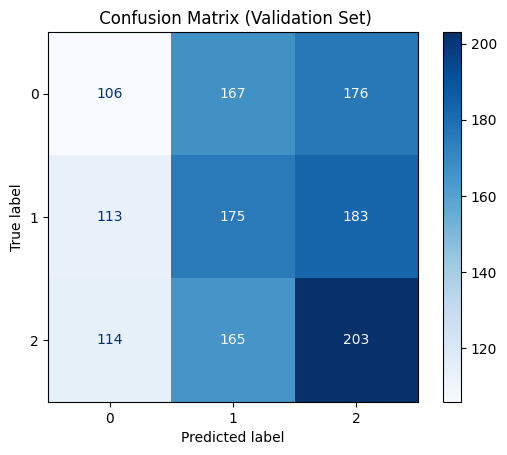

In [17]:
print('\nClassification Report:')
print(classification_report(y_test, y_pred_val))

cm = confusion_matrix(y_test, y_pred_val)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title(' Confusion Matrix (Validation Set)')
plt.show()


In [18]:
print("Class balance:", y_train.value_counts(normalize=True).sort_index())

from sklearn.feature_selection import mutual_info_classif
X_probe = pd.get_dummies(X_train, drop_first=True)
mi = mutual_info_classif(X_probe, y_train, discrete_features='auto', random_state=42)
mi_series = pd.Series(mi, index=X_probe.columns).sort_values(ascending=False)
print(mi_series.head(15))

Class balance: CGPA_bin
low       0.336484
medium    0.343438
high      0.320078
Name: proportion, dtype: float64
Course_Engineering                      0.015148
Substance_Use_Never                     0.012256
Course_Law                              0.008668
Extracurricular_Involvement_Moderate    0.008321
Sleep_Quality_Poor                      0.007881
Chronic_Illness_Yes                     0.007687
Course_Medical                          0.005445
Gender_Male                             0.005155
Physical_Activity_Low                   0.003978
Anxiety_Score                           0.002884
Sleep_Quality_Good                      0.002215
Course_Computer Science                 0.000000
Age                                     0.000000
Semester_Credit_Load                    0.000000
Financial_Stress                        0.000000
dtype: float64


After reflecting on our models performance, we can conclude that the available mental health and demographic features in this dataset have very limited predictive power for CGPA classification. Our MI score of 0.015 has very low association with CGPA. Most features show the MI value as nearly zero with our predicted key features like Anxiety_score at 0.003. Combined with the AUC at ~0.50, it indicated that for this data source, the relationship between mental health factors and academic performance it too weak to capture by standard classification models.

### Interpretation and discussion of results: 30 points

**1. Preprocessing decisions (~100 words)**
---
Decisions that had a big impact: 

- Splitting the CGPA data: Deciding on how to split the predicted data was the first step of this analysis. At first I manually selected bins but that lead to very unbalanced classes and primarily focused on high CGPA. I ended up going with quartiles to leave the binning even among the low, median and high CPGA_bins. Because of this, it could have very unclear boundaries between the classes which could lead to the model having a hard time separating everything out.

- A lot of our data was categorical with set values like (low, medium, and high). For this we used one-hot encoding to convert everything from cat. to binary. I think this was a good route to take because it kept everything consistent, and no new labels were introduced in the process. But I wonder if I were to have done that all manually if it would have led to clear feature separation therefore helping my models performance.

---

**2. Model selection reasoning (~75 words)**

Why did you choose the model you chose? Do not say "because it had the highest CV accuracy."
Explain what properties of the model made it appropriate for this dataset and task. If two
models had similar CV accuracy, what else informed your choice?

---

**3. Model Performance**

(reference the low MAX MI score )

**4. What made your model worse (~75 words)**


One thing that made our model worse was relying heavily on the original features without creating any new ones. We expected the existing variables like stress, sleep, and anxiety scores to be enough, but the model struggled to find strong patterns. Since these features individually do not have a strong relationship with CGPA, the models were not able to make accurate predictions. This showed that the dataset may need better feature engineering to capture more meaningful relationships.


---

**5. What you would do next (~50 words)**

If you had more time, what is the single most promising thing you would try next to improve
your score? Justify your answer based on what you observed in the data or your model's
error profile -- not just "try a more complex model."

If we had more time, the most promising next step would be trying a different target variable entirely instead of predicting CGPA bin, we would try predicting something like stress level or depression score, since our MI analysis showed those features have almost zero relationship with CGPA. The data may simply be better suited to a different prediction question.

---


**6. Conclusion**

After completing our full analysis, it became clear that the dataset itself was the biggest limiting factor in our results. Our mutual information analysis returned a max score of 0.015, meaning the mental health and lifestyle features in this dataset have almost no measurable relationship with CGPA. No matter what models we tried or how we tuned them, the signal just was not there to learn from. This is not a failure of the models themselves, Decision Tree, Random Forest, SVM, and CatBoost all told the same story. The data simply does not support the prediction we were trying to make, and that is something no amount of preprocessing or hyperparameter tuning can fix.